## CNN — Handwritten Digit Classification on MNIST

In this notebook we build a **Convolutional Neural Network (CNN)** to classify handwritten digits (0–9) from the classic MNIST dataset. CNNs are the standard architecture for image data because, unlike a plain Artificial Neural Network (ANN), they exploit the **spatial structure** of an image (nearby pixels are related) instead of treating every pixel as an independent, unordered feature.

We'll walk through: data loading & preprocessing → building the CNN → compiling → training → evaluation → visual diagnostics. At the very end, there's a detailed breakdown of **why ANN struggles with raw images** and **why CNN fixes it**, layer by layer.

### 1. Imports & Data Loading

We import NumPy/Pandas for data handling, Seaborn/Matplotlib for visualization, and Keras/TensorFlow for building the deep learning model. We also load the **MNIST dataset** — 70,000 grayscale images of handwritten digits, each `28x28` pixels, already split into train/test sets by Keras.

**Normalization**: Pixel values range from 0–255. Dividing by 255.0 scales them to `[0, 1]`. This helps the network train faster and more stably, since gradient-based optimizers converge better when inputs are on a similar small scale rather than large raw integer values.

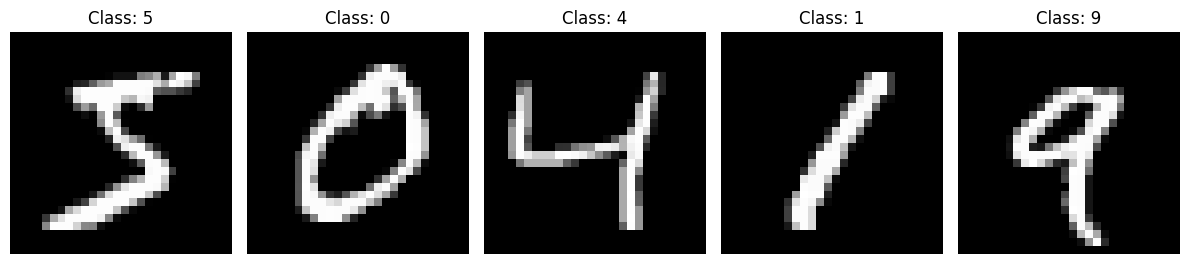

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, MaxPooling2D, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

class_names = ['0', '1', '2', '3', '4', '5',
               '6', '7', '8', '9']

# Normalize the pixxels
X_train, X_test = X_train / 255.0, X_test / 255.0

# Provide a few sample images with their corresponding labels.
sample_images = X_train[:5]
sample_labels = y_train[:5]

plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap="gray")
    plt.title(f"Class: {class_names[sample_labels[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Above we plot 5 sample training images with their true labels just to sanity-check that the data loaded and is labeled correctly before we build anything.

### 2. Building the CNN Architecture

```
Conv2D(32) → MaxPooling2D → Conv2D(64) → MaxPooling2D → Flatten → Dense(128) → Dropout(0.5) → Dense(10, softmax)
```

- **Conv2D(32, kernel_size=(3,3))**: Slides 32 different `3x3` filters (kernels) across the image to detect low-level patterns — edges, curves, corners. Each filter produces a "feature map." `input_shape=(28,28,1)` means single-channel (grayscale) 28x28 images.
- **MaxPooling2D(pool_size=(2,2))**: Downsamples each feature map by taking the max value in every `2x2` block. This shrinks the spatial size (less computation), keeps the strongest signals, and adds a bit of translation invariance (a digit shifted by a pixel or two still activates the same features).
- **Conv2D(64, kernel_size=(3,3))**: A second convolution stacked deeper learns higher-level, more abstract patterns (loops, strokes, digit-like shapes) built on top of the edges detected by the first layer.
- **Flatten()**: Converts the final 2D feature maps into a single 1D vector so they can be fed into the regular Dense (fully connected) layers.
- **Dense(128, activation="relu")**: A fully connected layer that combines all the extracted features to learn the final decision boundaries.
- **Dropout(0.5)**: Randomly "turns off" 50% of neurons during each training step. This prevents the network from over-relying on any specific neuron and reduces overfitting.
- **Dense(10, activation="softmax")**: The output layer — 10 neurons (one per digit class 0–9), with softmax converting raw scores into a probability distribution that sums to 1.

`cnn.summary()` prints the full layer-by-layer shape and parameter count, which is great for sanity-checking the architecture before training.

In [30]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])
cnn.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Compiling the Model

- **optimizer="adam"**: Adam adaptively adjusts the learning rate per parameter, which generally converges faster and more reliably than plain SGD.
- **loss="categorical_crossentropy"**: The standard loss for multi-class classification when labels are one-hot encoded. It penalizes the model heavily when it's confidently wrong.
- **metrics=["accuracy"]**: We track classification accuracy during training to monitor performance per epoch.

In [31]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

### 4. Reshaping Data & Training

- **Reshape to `(-1, 28, 28, 1)`**: Conv2D layers expect a 4D tensor: `(batch_size, height, width, channels)`. Since MNIST is grayscale, the channel dimension is `1` (it would be `3` for RGB images).
- **`to_categorical`**: Converts integer labels (e.g. `5`) into one-hot vectors (e.g. `[0,0,0,0,0,1,0,0,0,0]`), which is what `categorical_crossentropy` expects.
- **`fit(...)`**: Trains for 10 epochs with a batch size of 32, holding out 20% of the training data as a validation set to monitor generalization during training (not just training accuracy).

In [32]:
X_train_reshaped = X_train.reshape(-1, 28, 28, 1)
X_test_reshaped = X_test.reshape(-1, 28, 28, 1)

y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

history_cnn = cnn.fit(X_train_reshaped, y_train_encoded, epochs=10, batch_size=32, verbose=1, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9291 - loss: 0.2303 - val_accuracy: 0.9841 - val_loss: 0.0554
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9754 - loss: 0.0816 - val_accuracy: 0.9877 - val_loss: 0.0433
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9820 - loss: 0.0581 - val_accuracy: 0.9892 - val_loss: 0.0379
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9853 - loss: 0.0476 - val_accuracy: 0.9903 - val_loss: 0.0339
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9878 - loss: 0.0389 - val_accuracy: 0.9899 - val_loss: 0.0378
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9897 - loss: 0.0328 - val_accuracy: 0.9923 - val_loss: 0.0351
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9909 - loss: 0.0278 - val_accuracy: 0.9922 - val_loss: 0.0335
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9912 - loss: 0.0268 

### 5. Test Set Evaluation

We evaluate the trained model on the **unseen test set** to get an unbiased estimate of real-world performance. CNNs on MNIST typically reach **98–99% test accuracy** with an architecture like this.

In [33]:
acc_cnn = cnn.evaluate(X_test_reshaped, y_test_encoded, verbose=0)[1]
acc_cnn

0.9915000200271606

### 6. Training vs Validation Accuracy

Plotting train vs. validation accuracy across epochs helps diagnose the model's health:
- If both curves rise together and stay close → the model is generalizing well.
- If train accuracy keeps climbing while validation accuracy plateaus or drops → the model is overfitting (memorizing training data instead of learning generalizable patterns).

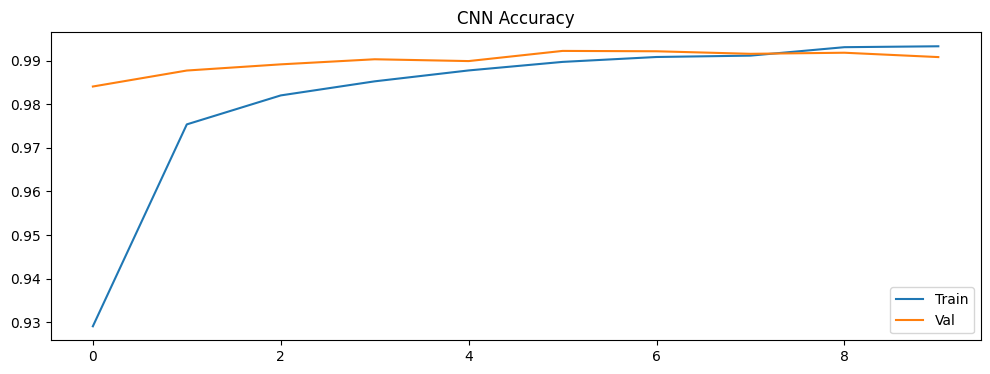

In [34]:
plt.figure(figsize=(12,4))
plt.plot(history_cnn.history['accuracy'], label="Train")
plt.plot(history_cnn.history['val_accuracy'], label="Val")
plt.title("CNN Accuracy")
plt.legend()
plt.show()

### 7. Confusion Matrix

The confusion matrix shows exactly which digits the model confuses with each other (e.g. is it mixing up 4s and 9s, or 3s and 8s?). The diagonal represents correct predictions — the brighter/heavier the diagonal, the better the model. Off-diagonal cells reveal specific error patterns that plain accuracy hides.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


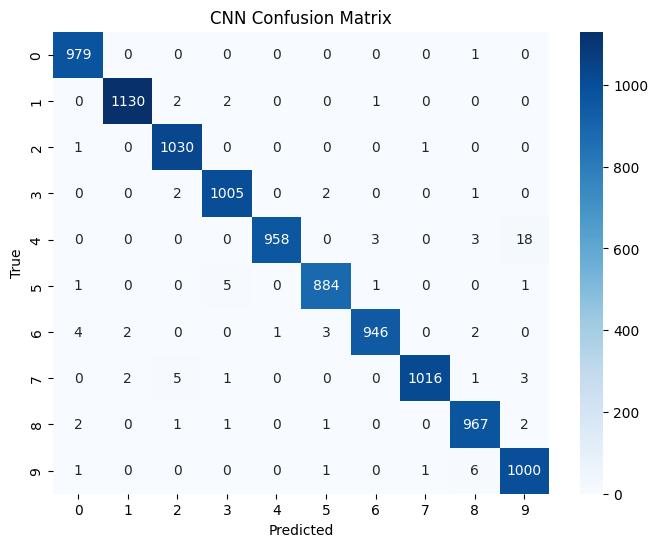

In [35]:
y_pred_cnn = np.argmax(cnn.predict(X_test_reshaped), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### 8. Visual Sanity Check on Test Samples

Finally, we visualize a few raw test images with their true labels, as a final qualitative sanity check that the dataset and labels line up correctly end-to-end.

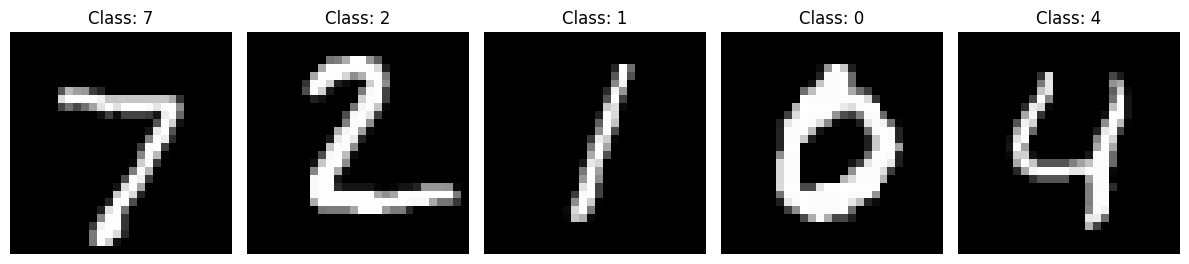

In [ ]:
random_idx = np.random.choice(len(X_train), 5, replace=False)
sample_images = X_train[random_idx]
sample_labels = y_train[random_idx]

plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap="gray")
    plt.title(f"Class: {class_names[sample_labels[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

---

## Why Not Just Use a Plain ANN for Images?

A natural question: MNIST images are small (`28x28 = 784` pixels) — why not just flatten them and feed them into a normal fully connected ANN? Here's why that approach is fundamentally weaker for image data, and why CNNs were invented to fix it.

### 1. ANN treats every pixel as an independent, unordered feature

In a plain ANN, you flatten the `28x28` image into a single 1D vector of `784` values and feed it into the input layer — **one node per pixel**. Each input node is fully connected to every neuron in the first hidden layer. This means:

- The network has **no concept of spatial structure**. Pixel `(0,0)` and pixel `(0,1)`, which are physically neighbors in the image, are treated exactly the same as if they were on opposite corners. The network must *re-learn* spatial relationships (edges, shapes) from scratch using brute-force weight combinations, instead of exploiting the fact that nearby pixels are usually correlated.
- Every single pixel — including background pixels that contribute nothing meaningful — is fed in and weighted individually. The network ends up learning weights for noise and irrelevant variation just as much as for the actual digit strokes, which is a major driver of **overfitting**: the model memorizes pixel-level quirks of the training images rather than learning general, reusable patterns like "a loop at the top + a vertical stroke = could be a 9."

### 2. Parameter explosion → vanishing gradients

With `784` input pixels, even a *modest* fully connected network blows up in parameter count fast:

- Input layer (`784` nodes) → Hidden layer 1 (say `784` nodes) = `784 × 784 ≈ 615,000` weights for just **one** layer.
- Add a second hidden layer of `784` nodes → another `784 × 784 ≈ 615,000` weights.
- That's well over a **million weights** for just two small hidden layers, before you even reach the output layer.

During backpropagation, the error gradient has to flow backward through *every one* of these weights, layer by layer, getting multiplied at each step by activation derivatives (e.g. sigmoid/tanh derivatives are always < 1). The more layers and weights you stack, the more these small fractional multiplications compound — gradients shrink exponentially as they propagate back toward the early layers. This is the **vanishing gradient problem**: early layers receive almost no meaningful gradient signal, so they barely update and effectively stop learning, while training becomes slow, unstable, and prone to getting stuck in poor solutions.

### 3. Other ANN limitations for images

- **No translation invariance**: a digit shifted a few pixels to the side, or written slightly larger/smaller, is seen as a completely different input pattern, since there's no positional flexibility built in.
- **Poor scalability**: this problem only gets worse for bigger, real-world images. A `224x224` RGB image has `224 × 224 × 3 ≈ 150,000` input pixels — fully connecting that to even a single hidden layer of modest size requires **billions** of weights, which is computationally infeasible and guarantees severe overfitting given limited training data.
- **No hierarchical feature learning**: ANNs learn one flat transformation from raw pixels to output; they don't naturally build up from simple patterns (edges) to complex ones (shapes, objects) the way visual systems (biological or artificial) benefit from.

### 4. How CNN solves all of this

CNNs are designed specifically around the structure of images, fixing each problem above:

- **`Conv2D` (Convolution)**: Instead of connecting every pixel to every neuron, a Conv2D layer slides a small filter (e.g. `3x3`) across the image, and that *same* filter (same small set of weights) is reused at every spatial location. This is called **weight sharing**, and it does two huge things: (1) it drastically cuts the number of trainable parameters compared to a fully connected layer, and (2) it directly preserves and exploits spatial structure, since each filter only looks at a local neighborhood of pixels, learning local patterns like edges, curves, and textures rather than memorizing global pixel positions.
- **Pooling (e.g. `MaxPooling2D`)**: Downsamples feature maps (e.g. taking the max value in every `2x2` region), which (1) shrinks the spatial dimensions going forward — fewer values to process in later layers, fewer parameters overall — and (2) adds a degree of **translation invariance**, since a feature shifted by a pixel or two still tends to produce a similar pooled output.
- **Stacking convolution layers (hierarchical features)**: Early conv layers learn simple, low-level features (edges, gradients). Deeper conv layers combine those into more complex, higher-level features (loops, strokes, shapes). This hierarchical build-up is far more efficient and generalizable than an ANN trying to learn everything in one flat step.
- **Fewer parameters → mitigated vanishing gradients**: because weight sharing and pooling dramatically reduce the number of parameters compared to a fully connected approach on raw pixels, there's less compounding/shrinking of gradients across an equivalent receptive field, and combined with modern activations like ReLU (whose gradient doesn't saturate the way sigmoid/tanh does), gradients flow back more effectively during training.
- **`Flatten()`**: After convolution and pooling have already extracted compact, meaningful spatial features, *then* we flatten into a 1D vector. This is the key difference from a plain ANN: by the time we flatten, the data isn't raw, noisy pixels anymore — it's a small set of distilled, high-level features.
- **`Dropout`**: Randomly disables a fraction of neurons during training, forcing the network to not over-rely on any single neuron/feature combination — a direct, complementary defense against overfitting, on top of what convolution and pooling already provide.
- **`Dense` (final layers)**: Once we have compact, spatially-aware features, regular fully connected Dense layers are perfectly fine and effective for the final classification decision — combining the extracted features into class probabilities via softmax.

**In short**: ANN forces every individual raw pixel into a massive, unstructured, fully-connected web of weights — wasteful, prone to overfitting, and a strong contributor to vanishing gradients. CNN instead extracts a small number of meaningful, spatially-aware features first (via shared-weight convolution + pooling), *then* hands a much smaller, richer representation to the dense layers — which is why CNNs dramatically outperform plain ANNs on image data, with far fewer parameters and far better generalization.